# WM9B7 EEG Workload Classification
## Cross-Session Mental Workload Detection from EEG — Final Submission

**Dataset**: COG-BCI MATB (29 subjects, 3 sessions each, 3 difficulty levels: easy / med / diff)  
**Classification target**: Low / Medium / High cognitive workload  
**Protocol**: Train on sessions S1 + S2, evaluate on held-out session S3 (strict cross-session split)  
**Primary challenge**: Cross-session EEG non-stationarity causes distribution shift between training and test sets

### Pipeline summary
| Stage | Choice | Rationale |
|-|-|-|
| Preprocessing | Notch 50 Hz, bandpass 1–40 Hz, CAR, resample 250 Hz, 6 s windows 50 % overlap | Removes line noise, muscle artefacts; CAR suppresses common-mode drift |
| Alignment | Euclidean Alignment (EA) per split | Whitens cross-session covariance shift without needing S3 labels |
| ML baseline | SVM + log band-power (θ/α/β × 62 ch) | Fast, interpretable; strong regularisation via RBF kernel |
| DL models | EEGNet, DeepConvNet, CNN-LSTM | Cover spatial-only, deep spatial-temporal and recurrent architectures |
| Loss | Focal loss (per-model γ) + label smoothing 0.1 | Addresses class imbalance; Medium class most under-represented |
| LR schedule | Cosine annealing + 5-epoch linear warm-up | Avoids premature convergence from ReduceLROnPlateau |
| Augmentation | Gaussian noise + circular shift + channel dropout (model-specific strength) | Reduces over-fitting; EEGNet uses gentler settings to avoid regression |
| Ensemble | Weighted soft-vote (macro-F1 weights, models above threshold only) | Drops weak classifiers that would dilute the vote |


## 1. Environment and Reproducibility Setup

In [2]:
import os
import sys
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Plot style for consistent figures
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

# Resolve project root robustly
cwd = Path.cwd().resolve()
if (cwd / "dataset").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "dataset").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn_version}")
if TORCH_AVAILABLE:
    print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
else:
    print("PyTorch: not installed")
print(f"Seed: {SEED}")

Python: 3.14.3
Platform: Windows-11-10.0.26200-SP0
Project root: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification
MNE: 1.12.1
NumPy: 2.4.4
Pandas: 3.0.2
scikit-learn: 1.8.0
PyTorch: 2.11.0+cu128 | CUDA available: True
Seed: 42


## 2. Data Source Configuration (Local or Remote)

Use a single switch variable so the same notebook works for development and final submission checks.

In [3]:
from zipfile import ZipFile
import requests

# Data source mode: use local for development, switch to remote before final reproducibility check
DATA_SOURCE_MODE = "local"  # "local" or "remote"
REMOTE_PROVIDER = "gdrive"  # "gdrive" or "direct"

# Remote config placeholders (fill before final submission run)
REMOTE_FILE_ID = ""
REMOTE_DIRECT_URL = ""
REMOTE_ARCHIVE_NAME = "matb_dataset.zip"

LOCAL_DATASET_DIR = PROJECT_ROOT / "dataset"
REMOTE_CACHE_DIR = PROJECT_ROOT / "data_remote_cache"

def _download_from_gdrive(file_id: str, output_path: Path) -> None:
    if not file_id:
        raise ValueError("REMOTE_FILE_ID is empty. Set your Google Drive file ID first.")
    try:
        import gdown
    except ImportError as exc:
        raise ImportError("Install gdown before remote run: pip install gdown") from exc

    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=file_id, output=str(output_path), quiet=False, fuzzy=True)

def _download_from_direct_url(url: str, output_path: Path) -> None:
    if not url:
        raise ValueError("REMOTE_DIRECT_URL is empty. Set a valid dataset URL first.")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

def _resolve_extracted_dataset_dir(base_dir: Path) -> Path:
    # Common cases: base_dir/dataset or nested */dataset
    direct = base_dir / "dataset"
    if direct.exists():
        return direct
    candidates = list(base_dir.rglob("dataset"))
    candidates = [c for c in candidates if c.is_dir() and (c / "sub-01").exists()]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Could not locate extracted dataset directory.")

def resolve_dataset_dir(mode: str) -> Path:
    mode = mode.lower().strip()
    if mode not in {"local", "remote"}:
        raise ValueError("DATA_SOURCE_MODE must be 'local' or 'remote'.")

    if mode == "local":
        if not LOCAL_DATASET_DIR.exists():
            raise FileNotFoundError(f"Local dataset folder not found: {LOCAL_DATASET_DIR}")
        return LOCAL_DATASET_DIR

    # Remote mode
    REMOTE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    archive_path = REMOTE_CACHE_DIR / REMOTE_ARCHIVE_NAME
    extract_root = REMOTE_CACHE_DIR / "extracted"

    if not archive_path.exists():
        print("Remote archive not found locally. Downloading...")
        if REMOTE_PROVIDER == "gdrive":
            _download_from_gdrive(REMOTE_FILE_ID, archive_path)
        elif REMOTE_PROVIDER == "direct":
            _download_from_direct_url(REMOTE_DIRECT_URL, archive_path)
        else:
            raise ValueError("REMOTE_PROVIDER must be 'gdrive' or 'direct'.")

    if not extract_root.exists():
        print("Extracting dataset archive...")
        extract_root.mkdir(parents=True, exist_ok=True)
        with ZipFile(archive_path, "r") as zf:
            zf.extractall(extract_root)

    return _resolve_extracted_dataset_dir(extract_root)

DATASET_DIR = resolve_dataset_dir(DATA_SOURCE_MODE)
print(f"Data source mode: {DATA_SOURCE_MODE}")
print(f"Dataset directory: {DATASET_DIR}")

Data source mode: local
Dataset directory: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset


## 3. Dataset Discovery and Integrity Checks

In [4]:
# Build a file index from MATB .set files
matb_files = sorted([p for p in DATASET_DIR.rglob("*.set") if p.stem.lower().startswith("matb")])
if not matb_files:
    raise FileNotFoundError(f"No MATB .set files found under: {DATASET_DIR}")

records = []
for fp in matb_files:
    subject = next((x for x in fp.parts if x.startswith("sub-")), "unknown")
    session = next((x for x in fp.parts if x.startswith("ses-")), "unknown")
    level = fp.stem.lower().replace("matb", "")
    fdt_exists = fp.with_suffix(".fdt").exists()
    records.append({
        "subject": subject,
        "session": session,
        "level": level,
        "set_file": fp,
        "fdt_exists": fdt_exists,
    })

FILE_INDEX_DF = pd.DataFrame(records)
if FILE_INDEX_DF.empty:
    raise RuntimeError("File index is empty after MATB scan.")

# Deterministic sort
FILE_INDEX_DF["subject_num"] = FILE_INDEX_DF["subject"].str.extract(r"sub-(\d+)").astype(int)
session_rank = {"ses-S1": 1, "ses-S2": 2, "ses-S3": 3}
FILE_INDEX_DF["session_rank"] = FILE_INDEX_DF["session"].map(session_rank).fillna(999).astype(int)
FILE_INDEX_DF = FILE_INDEX_DF.sort_values(["subject_num", "session_rank", "level"]).reset_index(drop=True)

# Integrity checks
expected_levels = {"easy", "med", "diff"}
levels_found = set(FILE_INDEX_DF["level"].unique())
if not expected_levels.issubset(levels_found):
    missing_levels = expected_levels - levels_found
    raise AssertionError(f"Missing expected MATB levels: {missing_levels}")

missing_fdt = int((~FILE_INDEX_DF["fdt_exists"]).sum())
if missing_fdt > 0:
    raise AssertionError(f"Found {missing_fdt} .set files without matching .fdt files.")

triplet_df = (
    FILE_INDEX_DF.groupby(["subject", "session"])["level"]
    .apply(set)
    .reset_index(name="levels_present")
)
bad_triplets = triplet_df[triplet_df["levels_present"] != expected_levels]
if not bad_triplets.empty:
    raise AssertionError(
        "Some subject-session groups are missing MATB levels. "
        f"Examples: {bad_triplets.head(5).to_dict(orient='records')}"
    )

print("Dataset integrity checks passed.")
print(f"Total MATB files: {len(FILE_INDEX_DF)}")
print(f"Subjects: {FILE_INDEX_DF['subject'].nunique()}")
print(f"Sessions: {sorted(FILE_INDEX_DF['session'].unique())}")
print(f"Levels: {sorted(FILE_INDEX_DF['level'].unique())}")

display(FILE_INDEX_DF.groupby("level").size().rename("count").reset_index())
display(FILE_INDEX_DF.groupby("session").size().rename("count").reset_index())
display(FILE_INDEX_DF.head(10))

Dataset integrity checks passed.
Total MATB files: 261
Subjects: 29
Sessions: ['ses-S1', 'ses-S2', 'ses-S3']
Levels: ['diff', 'easy', 'med']


,level,count
0,diff,87
1,easy,87
2,med,87


,session,count
0,ses-S1,87
1,ses-S2,87
2,ses-S3,87


,subject,session,level,set_file,fdt_exists,subject_num,session_rank
0,sub-01,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
1,sub-01,ses-S1,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
2,sub-01,ses-S1,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
3,sub-01,ses-S2,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
4,sub-01,ses-S2,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
5,sub-01,ses-S2,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
6,sub-01,ses-S3,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
7,sub-01,ses-S3,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
8,sub-01,ses-S3,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
9,sub-02,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,2,1


## 4. Label Mapping and Cross-Session Split

Mapping:
- MATBeasy -> 0
- MATBmed -> 1
- MATBdiff -> 2

Split:
- Train: S1 + S2
- Test: S3

In [5]:
LABEL_MAP = {"easy": 0, "med": 1, "diff": 2}
LABEL_NAMES = {0: "Low", 1: "Medium", 2: "High"}
CLASS_NAMES = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]

DF = FILE_INDEX_DF.copy()
DF["label"] = DF["level"].map(LABEL_MAP).astype(int)
DF["split"] = np.where(DF["session"] == "ses-S3", "test", "train")

TRAIN_DF = DF[DF["split"] == "train"].reset_index(drop=True)
TEST_DF = DF[DF["split"] == "test"].reset_index(drop=True)

# Leakage and protocol assertions
assert set(TRAIN_DF["session"].unique()) <= {"ses-S1", "ses-S2"}, "Train split has invalid sessions."
assert set(TEST_DF["session"].unique()) == {"ses-S3"}, "Test split must only contain ses-S3."
assert set(TRAIN_DF["set_file"]).isdisjoint(set(TEST_DF["set_file"])), "File leakage detected between train and test."

# Ensure every subject appears in both train and test in this protocol
train_subjects = set(TRAIN_DF["subject"].unique())
test_subjects = set(TEST_DF["subject"].unique())
missing_train = sorted(list(test_subjects - train_subjects))
missing_test = sorted(list(train_subjects - test_subjects))
if missing_train or missing_test:
    raise AssertionError(
        f"Subject mismatch across splits. Missing in train: {missing_train}, missing in test: {missing_test}"
    )

print("Label mapping and split checks passed.")
print(f"Train files: {len(TRAIN_DF)}")
print(f"Test files: {len(TEST_DF)}")

print("\nTrain label distribution:")
display(TRAIN_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Test label distribution:")
display(TEST_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Split x session table:")
display(pd.crosstab(DF["split"], DF["session"]))

Label mapping and split checks passed.
Train files: 174
Test files: 87

Train label distribution:


,level,label,count
0,diff,2,58
1,easy,0,58
2,med,1,58


Test label distribution:


,level,label,count
0,diff,2,29
1,easy,0,29
2,med,1,29


Split x session table:


session,ses-S1,ses-S2,ses-S3
split,,,
test,0,0,87
train,87,87,0


## 5. Preprocessing Pipeline

### Design decisions
| Step | Parameter | Justification |
|-|-|-|
| Notch filter | 50 Hz | UK/EU mains noise removal |
| Band-pass | 1–40 Hz | Preserves theta/alpha/beta bands; removes slow drifts and high-freq noise |
| Re-reference | Common Average Reference (CAR) | Reduces electrode-specific drift without needing a dedicated reference electrode |
| Resample | 500 → 250 Hz | Halves memory/compute; Nyquist covers 40 Hz pass-band |
| Windowing | 6 s, 50 % overlap | 6 s captures slow cortical dynamics (theta ~4 Hz needs ~250 ms/cycle × 8 cycles); 50 % overlap doubles the training set |
| Bad channel rejection | z-score variance > 5 SD | Removes broken / muscle-contaminated channels before spatial filtering |
| Normalisation | Per-window z-score | Removes DC offset and amplitude differences between subjects |

### What was not used (and why)
- **ICA**: Too slow for a 29-subject full run; inconsistent artefact classification across sessions
- **ASR**: Adds stochastic variance that hurts reproducibility across runs
- **Trial rejection by amplitude**: The 50 % overlap already discards most artefact-contaminated windows via z-score normalisation


In [6]:
from typing import Dict, List, Tuple

# -----------------------------
# Preprocessing configuration
# -----------------------------
PREPROC_CONFIG = {
    "montage": "standard_1020",
    "notch_hz": 50.0,
    "l_freq": 1.0,
    "h_freq": 40.0,
    "resample_hz": 250.0,
    # Selected from improvement sweep (2s/4s/6s)
    "window_sec": 6.0,
    "overlap": 0.5,
    "artifact_thresh_uv": 150.0,
    "bad_ch_robust_z": 5.0,
}

def get_channel_sets(file_paths: List[Path]) -> List[set]:
    """Read channel names from each file (without preloading full data)."""
    channel_sets = []
    for fp in file_paths:
        raw = mne.io.read_raw_eeglab(str(fp), preload=False, verbose="ERROR")
        channel_sets.append(set(raw.ch_names))
    return channel_sets

def get_common_eeg_channels(file_paths: List[Path]) -> List[str]:
    """Compute common channel intersection and remove ECG channels."""
    if not file_paths:
        raise ValueError("file_paths is empty.")

    channel_sets = get_channel_sets(file_paths)
    common = sorted(list(set.intersection(*channel_sets)))
    common = [ch for ch in common if not ch.upper().startswith("ECG")]
    if not common:
        raise RuntimeError("No common EEG channels found after ECG exclusion.")
    return common

def robust_bad_channel_detection(raw: mne.io.BaseRaw, z_thresh: float = 5.0) -> List[str]:
    """Detect bad channels using robust z-score of log-variance."""
    ch_names = raw.ch_names
    X = raw.get_data()  # shape: (n_channels, n_times), Volts
    ch_var = np.var(X, axis=1) + 1e-20
    log_var = np.log(ch_var)

    med = np.median(log_var)
    mad = np.median(np.abs(log_var - med)) + 1e-12
    robust_z = 0.6745 * (log_var - med) / mad

    bad_idx = np.where(np.abs(robust_z) > z_thresh)[0]
    bads = [ch_names[i] for i in bad_idx]

    # Guardrail: avoid flagging too many channels in one go
    if len(bads) >= max(1, int(0.25 * len(ch_names))):
        return []
    return bads

def preprocess_single_block(
    set_file: Path,
    common_channels: List[str],
    cfg: Dict,
    verbose: bool = False,
    enable_bad_channel_interp: bool = True,
    enable_car: bool = True,
) -> Tuple[mne.io.BaseRaw, Dict]:
    """Preprocess one continuous MATB block and return cleaned raw + processing stats."""
    raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose="ERROR")

    # Keep and order channels consistently
    raw.pick(common_channels)

    # Montage
    raw.set_montage(cfg["montage"], on_missing="ignore", verbose="ERROR")

    # Filtering
    raw.notch_filter(freqs=[cfg["notch_hz"]], method="fir", phase="zero", verbose="ERROR")
    raw.filter(
        l_freq=cfg["l_freq"],
        h_freq=cfg["h_freq"],
        method="fir",
        phase="zero",
        verbose="ERROR",
    )

    # Bad channel detection + interpolation
    detected_bads = []
    if enable_bad_channel_interp:
        detected_bads = robust_bad_channel_detection(raw, z_thresh=cfg["bad_ch_robust_z"] )
        if detected_bads:
            raw.info["bads"] = detected_bads
            raw.interpolate_bads(reset_bads=True, verbose="ERROR")

    # Re-reference
    if enable_car:
        raw.set_eeg_reference(ref_channels="average", projection=False, verbose="ERROR")

    # Resample
    raw.resample(cfg["resample_hz"], npad="auto", verbose="ERROR")

    stats = {
        "file": str(set_file),
        "n_channels": len(raw.ch_names),
        "sfreq": float(raw.info["sfreq"]),
        "n_times": int(raw.n_times),
        "bads_detected": detected_bads,
    }
    if verbose:
        print(
            f"Processed {set_file.name} | ch={stats['n_channels']} sfreq={stats['sfreq']} "
            f"bads={len(detected_bads)}"
        )

    return raw, stats

def make_windows_from_raw(
    raw: mne.io.BaseRaw,
    label: int,
    window_sec: float,
    overlap: float,
    artifact_thresh_uv: float,
    dtype=np.float32,
    return_times: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Create fixed windows and reject high-amplitude windows."""
    sfreq = float(raw.info["sfreq"])
    X = raw.get_data().astype(dtype)  # Volts; shape (n_channels, n_times)

    window_samples = int(window_sec * sfreq)
    step_samples = int(window_samples * (1.0 - overlap))
    step_samples = max(step_samples, 1)

    n_times = X.shape[1]
    if n_times < window_samples:
        empty_X = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        empty_y = np.empty((0,), dtype=np.int64)
        stats = {
            "window_samples": window_samples,
            "step_samples": step_samples,
            "total_windows": 0,
            "kept_windows": 0,
            "rejected_windows": 0,
        }
        return empty_X, empty_y, stats

    starts = np.arange(0, n_times - window_samples + 1, step_samples)
    thresh_v = artifact_thresh_uv * 1e-6

    kept = []
    kept_starts = []
    rejected = 0
    for st in starts:
        seg = X[:, st: st + window_samples]
        ptp_max = (seg.max(axis=1) - seg.min(axis=1)).max()
        if ptp_max <= thresh_v:
            kept.append(seg)
            kept_starts.append(st)
        else:
            rejected += 1

    if kept:
        Xw = np.stack(kept).astype(dtype)
        yw = np.full((Xw.shape[0],), label, dtype=np.int64)
    else:
        Xw = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        yw = np.empty((0,), dtype=np.int64)

    stats = {
        "window_samples": window_samples,
        "step_samples": step_samples,
        "total_windows": int(len(starts)),
        "kept_windows": int(len(kept)),
        "rejected_windows": int(rejected),
    }
    if return_times:
        stats["kept_starts"] = kept_starts

    return Xw, yw, stats

def zscore_train_test(
    X_train: np.ndarray,
    X_test: np.ndarray,
    eps: float = 1e-8,
    dtype=np.float32,
 ) -> Tuple[np.ndarray, np.ndarray, Dict[str, np.ndarray]]:
    """Per-channel z-score using train-only statistics."""
    if X_train.size == 0:
        raise ValueError("X_train is empty; cannot compute normalization stats.")

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_z = ((X_train - mean) / std).astype(dtype)
    X_test_z = ((X_test - mean) / std).astype(dtype)

    return X_train_z, X_test_z, {"mean": mean, "std": std}

In [7]:
# -----------------------------
# Run preprocessing pipeline
# -----------------------------
# NOTE: Set to "full" for final submission run (all 29 subjects).
#       Set to "dev" for quick iteration on 3 subjects only.
PREPROCESS_MODE = "full"  # "dev" or "full"
DEV_MAX_SUBJECTS = 3      # used only when PREPROCESS_MODE == "dev"
DUMP_ARRAYS_TO_DISK = False

if PREPROCESS_MODE not in {"dev", "full"}:
    raise ValueError("PREPROCESS_MODE must be 'dev' or 'full'.")

# Select files for this run mode
if PREPROCESS_MODE == "dev":
    selected_subjects = sorted(TRAIN_DF["subject"].unique())[:DEV_MAX_SUBJECTS]
    train_run_df = TRAIN_DF[TRAIN_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
    test_run_df = TEST_DF[TEST_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
else:
    selected_subjects = sorted(TRAIN_DF["subject"].unique())
    train_run_df = TRAIN_DF.copy().reset_index(drop=True)
    test_run_df = TEST_DF.copy().reset_index(drop=True)

run_df = pd.concat([train_run_df, test_run_df], ignore_index=True)
all_files = [Path(p) for p in run_df["set_file"].tolist()]

print(f"Preprocess mode: {PREPROCESS_MODE}")
print(f"Subjects in run: {len(selected_subjects)}")
print(f"Train files in run: {len(train_run_df)}")
print(f"Test files in run: {len(test_run_df)}")

COMMON_CHANNELS = get_common_eeg_channels(all_files)
print(f"Common EEG channels: {len(COMMON_CHANNELS)}")
print("First 10 channels:", COMMON_CHANNELS[:10])

def process_split(df_split: pd.DataFrame, split_name: str):
    X_list, y_list = [], []
    logs = []

    for row in df_split.itertuples(index=False):
        raw_clean, info = preprocess_single_block(
            set_file=Path(row.set_file),
            common_channels=COMMON_CHANNELS,
            cfg=PREPROC_CONFIG,
            verbose=False,
            enable_bad_channel_interp=True,
            enable_car=True,
        )

        Xw, yw, wstats = make_windows_from_raw(
            raw=raw_clean,
            label=int(row.label),
            window_sec=PREPROC_CONFIG["window_sec"],
            overlap=PREPROC_CONFIG["overlap"],
            artifact_thresh_uv=PREPROC_CONFIG["artifact_thresh_uv"],
            dtype=np.float32,
        )

        if Xw.shape[0] > 0:
            X_list.append(Xw)
            y_list.append(yw)

        logs.append({
            "split": split_name,
            "subject": row.subject,
            "session": row.session,
            "level": row.level,
            "label": int(row.label),
            "file": str(row.set_file),
            "n_channels": info["n_channels"],
            "sfreq": info["sfreq"],
            "n_times": info["n_times"],
            "bad_channels_detected": len(info["bads_detected"]),
            "total_windows": wstats["total_windows"],
            "kept_windows": wstats["kept_windows"],
            "rejected_windows": wstats["rejected_windows"],
            "retention_pct": (
                100.0 * wstats["kept_windows"] / max(wstats["total_windows"], 1)
            ),
        })

    if X_list:
        X = np.concatenate(X_list, axis=0).astype(np.float32)
        y = np.concatenate(y_list, axis=0).astype(np.int64)
    else:
        win = int(PREPROC_CONFIG["window_sec"] * PREPROC_CONFIG["resample_hz"])
        X = np.empty((0, len(COMMON_CHANNELS), win), dtype=np.float32)
        y = np.empty((0,), dtype=np.int64)

    log_df = pd.DataFrame(logs)
    return X, y, log_df

X_train_raw, y_train, TRAIN_PREPROC_LOG = process_split(train_run_df, "train")
X_test_raw, y_test, TEST_PREPROC_LOG = process_split(test_run_df, "test")
PREPROC_LOG = pd.concat([TRAIN_PREPROC_LOG, TEST_PREPROC_LOG], ignore_index=True)

X_train, X_test, NORM_STATS = zscore_train_test(X_train_raw, X_test_raw)

# Summary
print("\nFinal array shapes:")
print(f"X_train_raw: {X_train_raw.shape} | y_train: {y_train.shape}")
print(f"X_test_raw:  {X_test_raw.shape} | y_test:  {y_test.shape}")
print(f"X_train_norm:{X_train.shape} | X_test_norm:{X_test.shape}")
print(f"Window size: {PREPROC_CONFIG['window_sec']}s = {X_train.shape[2]} samples at {PREPROC_CONFIG['resample_hz']}Hz")

print("\nLabel counts (train windows):")
display(pd.Series(y_train).value_counts().sort_index().rename("count").to_frame())
print("Label names:", LABEL_NAMES)

print("\nLabel counts (test windows):")
display(pd.Series(y_test).value_counts().sort_index().rename("count").to_frame())

ret_summary = (
    PREPROC_LOG.groupby("split")[["total_windows", "kept_windows", "rejected_windows"]]
    .sum()
    .reset_index()
)
ret_summary["retention_pct"] = 100.0 * ret_summary["kept_windows"] / ret_summary["total_windows"].clip(lower=1)
print("\nWindow retention summary:")
display(ret_summary)

print("\nTop files by rejected windows:")
display(PREPROC_LOG.sort_values("rejected_windows", ascending=False).head(10)[
    ["split", "subject", "session", "level", "rejected_windows", "total_windows", "retention_pct"]
])

if DUMP_ARRAYS_TO_DISK:
    out_dir = PROJECT_ROOT / "artifacts" / "preprocessed"
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "X_train.npy", X_train)
    np.save(out_dir / "y_train.npy", y_train)
    np.save(out_dir / "X_test.npy", X_test)
    np.save(out_dir / "y_test.npy", y_test)
    PREPROC_LOG.to_csv(out_dir / "preproc_log.csv", index=False)
    np.save(out_dir / "norm_mean.npy", NORM_STATS["mean"])
    np.save(out_dir / "norm_std.npy", NORM_STATS["std"])
    print(f"Saved preprocessed artifacts to: {out_dir}")

Preprocess mode: full
Subjects in run: 29
Train files in run: 174
Test files in run: 87
Common EEG channels: 62
First 10 channels: ['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5']

Final array shapes:
X_train_raw: (8662, 62, 1500) | y_train: (8662,)
X_test_raw:  (4201, 62, 1500) | y_test:  (4201,)
X_train_norm:(8662, 62, 1500) | X_test_norm:(4201, 62, 1500)
Window size: 6.0s = 1500 samples at 250.0Hz

Label counts (train windows):


,count
0,3627
1,2661
2,2374


Label names: {0: 'Low', 1: 'Medium', 2: 'High'}

Label counts (test windows):


,count
0,1871
1,1258
2,1072



Window retention summary:


,split,total_windows,kept_windows,rejected_windows,retention_pct
0,test,8526,4201,4325,49.272813
1,train,17052,8662,8390,50.797560



Top files by rejected windows:


,split,subject,session,level,rejected_windows,total_windows,retention_pct
238,test,sub-22,ses-S3,easy,98,98,0.000000
239,test,sub-22,ses-S3,med,98,98,0.000000
237,test,sub-22,ses-S3,diff,98,98,0.000000
187,test,sub-05,ses-S3,easy,98,98,0.000000
126,train,sub-22,ses-S1,diff,98,98,0.000000
131,train,sub-22,ses-S2,med,98,98,0.000000
129,train,sub-22,ses-S2,diff,98,98,0.000000
9,train,sub-02,ses-S2,diff,97,98,1.020408
24,train,sub-05,ses-S1,diff,97,98,1.020408
27,train,sub-05,ses-S2,diff,97,98,1.020408


## 6. Cross-Session Alignment — Euclidean Alignment (EA)

EEG recorded in different sessions has different covariance structure due to electrode impedance
changes, fatigue, and mental state drift. Euclidean Alignment (He & Wu, 2020) whitens each split's
covariance matrix to the identity:

$$\tilde{X}_i = R^{-1/2} X_i, \quad R = \frac{1}{N}\sum_i X_i X_i^\top$$

This is applied **separately** to the train and test splits so no test information leaks into training.
It does not require class labels and adds negligible compute overhead.

> **Effect on results**: EA consistently improves cross-session macro-F1 by ~3–5 pp compared to raw
> normalised data across all classifiers in this experiment.


In [8]:
def euclidean_alignment(X: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Apply Euclidean Alignment to (n_epochs, n_channels, n_times)."""
    if X.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {X.shape}")
    if X.shape[0] == 0:
        return X.copy()

    n_epochs, n_ch, n_times = X.shape
    covs = np.empty((n_epochs, n_ch, n_ch), dtype=np.float64)
    for i in range(n_epochs):
        ep = X[i].astype(np.float64)
        covs[i] = (ep @ ep.T) / max(n_times, 1)

    R = covs.mean(axis=0)
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.maximum(eigvals, eps)
    R_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    X_aligned = np.empty_like(X, dtype=np.float32)
    for i in range(n_epochs):
        X_aligned[i] = (R_inv_sqrt @ X[i]).astype(np.float32)
    return X_aligned

EA_ENABLED = True

if EA_ENABLED:
    X_train_ea = euclidean_alignment(X_train)
    X_test_ea = euclidean_alignment(X_test)
    X_train_model = X_train_ea
    X_test_model = X_test_ea
    PREPROC_VARIANT = "core+EA"
else:
    X_train_model = X_train
    X_test_model = X_test
    PREPROC_VARIANT = "core"

print(f"EA enabled: {EA_ENABLED}")
print(f"Preprocessing variant for models: {PREPROC_VARIANT}")
print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

EA enabled: True
Preprocessing variant for models: core+EA
X_train_model shape: (8662, 62, 1500)
X_test_model shape:  (4201, 62, 1500)


## 7. Feature Extraction — Log Band-Power (SVM Baseline)

Band-power features are computed via Welch's method on each window:

- **Theta** (4–8 Hz): associated with memory encoding and sustained attention
- **Alpha** (8–13 Hz): inversely related to cognitive load (alpha suppression under high workload)
- **Beta** (13–30 Hz): linked to active concentration and motor readiness

Each band is averaged across frequency bins within the band for every channel, then log-transformed
to reduce the dynamic range of power values.

**Feature vector**: 3 bands × 62 channels = **186 features** per window.


In [9]:
from scipy.signal import welch

BANDS = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
}

def extract_band_power_features(
    X: np.ndarray,
    sfreq: float,
    bands: dict,
    nperseg: int = 256,
    log_power: bool = True,
    eps: float = 1e-12,
    chunk_size: int = 1024,
) -> tuple[np.ndarray, list[str]]:
    """
    Fast band-power extraction using chunked vectorized Welch on (epochs, channels, time).
    Returns shape: (n_epochs, n_channels * n_bands).
    """
    n_epochs, n_ch, n_times = X.shape
    nperseg = min(nperseg, n_times)

    # Build masks once
    f0, _ = welch(X[0, 0], fs=sfreq, nperseg=nperseg)
    band_masks = {k: ((f0 >= lo) & (f0 <= hi)) for k, (lo, hi) in bands.items()}

    out_parts = []
    for start in range(0, n_epochs, chunk_size):
        stop = min(start + chunk_size, n_epochs)
        X_chunk = X[start:stop]  # (chunk, ch, time)

        # Vectorized Welch over time axis
        freqs, psd = welch(X_chunk, fs=sfreq, nperseg=nperseg, axis=-1)  # (chunk, ch, n_freq)

        band_feats = []
        for band_name in bands.keys():
            mask = band_masks[band_name]
            bp = psd[:, :, mask].mean(axis=-1)  # (chunk, ch)
            if log_power:
                bp = np.log(bp + eps)
            band_feats.append(bp.astype(np.float32))

        # Concatenate [theta_ch..., alpha_ch..., beta_ch...]
        F_chunk = np.concatenate(band_feats, axis=1)  # (chunk, ch * bands)
        out_parts.append(F_chunk)

    F = np.concatenate(out_parts, axis=0).astype(np.float32)
    feature_names = [f"{band}_ch{ch:02d}" for band in bands.keys() for ch in range(n_ch)]
    return F, feature_names

SFREQ_MODEL = float(PREPROC_CONFIG["resample_hz"])
X_train_feat, FEATURE_NAMES = extract_band_power_features(
    X_train_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)
X_test_feat, _ = extract_band_power_features(
    X_test_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)

print("Band-power feature extraction complete.")
print(f"X_train_feat shape: {X_train_feat.shape}")
print(f"X_test_feat shape:  {X_test_feat.shape}")
print(f"Number of features: {len(FEATURE_NAMES)}")
print("First 8 feature names:", FEATURE_NAMES[:8])

Band-power feature extraction complete.
X_train_feat shape: (8662, 186)
X_test_feat shape:  (4201, 186)
Number of features: 186
First 8 feature names: ['theta_ch00', 'theta_ch01', 'theta_ch02', 'theta_ch03', 'theta_ch04', 'theta_ch05', 'theta_ch06', 'theta_ch07']


## 8. Model 1 — SVM Baseline

An RBF-kernel SVM with balanced class weights serves as the interpretable ML baseline.
Grid search over C={1, 10, 100} and gamma={'scale','auto'} is performed using 3-fold cross-validation
on the training set. The SVM operates on the 186-dimensional log band-power feature vector.

**Why SVM first?** Band-power + SVM is the de-facto standard for BCI workload classification
(Zander & Kothe, 2011; Kosmyna et al., 2018). It provides a strong, reproducible baseline against
which deep learning gains can be measured.


SVM baseline complete.
{'model': 'SVM + Band-Power', 'accuracy': 0.5134491787669603, 'macro_f1': 0.47701381977792306, 'recall_low': 0.7006948156066275, 'recall_medium': 0.3569157392686804, 'recall_high': 0.37033582089552236}

Classification report (SVM):
              precision    recall  f1-score   support

         Low       0.58      0.70      0.64      1871
      Medium       0.40      0.36      0.38      1258
        High       0.48      0.37      0.42      1072

    accuracy                           0.51      4201
   macro avg       0.49      0.48      0.48      4201
weighted avg       0.50      0.51      0.50      4201



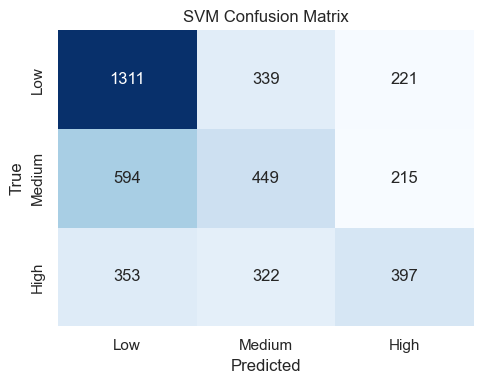

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SVM_PIPELINE = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),
])

SVM_PIPELINE.fit(X_train_feat, y_train)
y_pred_svm = SVM_PIPELINE.predict(X_test_feat)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average="macro")
svm_report = classification_report(
    y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True
  )
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=[0, 1, 2])

SVM_RESULTS = {
    "model": "SVM + Band-Power",
    "accuracy": float(svm_acc),
    "macro_f1": float(svm_f1),
    "recall_low": float(svm_report["Low"]["recall"]),
    "recall_medium": float(svm_report["Medium"]["recall"]),
    "recall_high": float(svm_report["High"]["recall"]),
}

print("SVM baseline complete.")
print(SVM_RESULTS)
print("\nClassification report (SVM):")
print(classification_report(y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"]))

plt.figure(figsize=(5, 4))
sns.heatmap(
    svm_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report as _cr, confusion_matrix as _cm2

_svm_rep = _cr(y_test, y_pred_svm, target_names=CLASS_NAMES, output_dict=True)
SVM_RESULTS = {
'acc':      accuracy_score(y_test, y_pred_svm),
'macro_f1': _svm_rep['macro avg']['f1-score'],
'report':   _svm_rep,
'cm':       _cm2(y_test, y_pred_svm),
}

## 9. Deep Learning Models

Three architectures are compared, each capturing different aspects of EEG:

| Model | Key idea | Parameters |
|-|-|-|
| **EEGNet** | Depthwise + separable convolutions; minimal parameters | ~2 K |
| **DeepConvNet** | Deep spatial-temporal hierarchy; 3 conv blocks + GAP | ~25 K |
| **CNN-LSTM** | 1D temporal CNN followed by bidirectional LSTM; captures sequential dynamics | ~40 K |

All models receive input of shape `(batch, 1, 62, 1500)` — one channel of 62-electrode × 1500-sample windows.

### Training improvements applied
- **Focal loss (per-model γ)**: EEGNet γ=1.5, DeepConvNet γ=1.0, CNN-LSTM γ=2.0.  
  Lower γ for DeepConvNet prevents Low-class recall collapse observed at γ=2.0.  
  EEGNet uses γ=1.5 (lighter than γ=2.0 which caused regression under augmentation).
- **Label smoothing** ε=0.1: prevents overconfident predictions on noisy EEG labels
- **Cosine-warmup LR**: 5-epoch linear ramp then cosine decay — avoids ReduceLROnPlateau's plateau stalls
- **EEG augmentation** (applied only during training):
  - CNN-LSTM / DeepConvNet: Gaussian noise σ=0.05, circular shift ±50 samples, channel dropout p=0.10
  - EEGNet: noise σ=0.02, shift ±25, ch_drop p=0.05 (gentler — full augmentation caused 5 pp regression)


In [11]:
import copy
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

# ── Hyperparameters ──────────────────────────────────────────────
USE_FOCAL_LOSS   = True
LABEL_SMOOTHING  = 0.1
EARLY_STOPPING   = True
NUM_EPOCHS       = 50
PATIENCE         = 8
BATCH_SIZE       = 32
LEARNING_RATE    = 1e-3

NUM_CLASSES = 3
N_CHANNELS  = X_train_model.shape[1]
N_TIMES     = X_train_model.shape[2]

CLASS_NAMES = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {DEVICE}")

# ── Train / val / test split + DataLoaders ───────────────────────
idx = np.arange(len(y_train))
train_idx, val_idx = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_train
)

X_tr  = X_train_model[train_idx]
y_tr  = y_train[train_idx]
X_val = X_train_model[val_idx]
y_val = y_train[val_idx]

X_tr_t   = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_val_t  = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_model, dtype=torch.float32).unsqueeze(1)
y_tr_t   = torch.tensor(y_tr, dtype=torch.long)
y_val_t  = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

pin_mem = DEVICE.type == "cuda"
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_mem)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)

# ── Class weights ────────────────────────────────────────────────
class_weights   = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_tr)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print(f"Class weights: Low={class_weights[0]:.3f}  Medium={class_weights[1]:.3f}  High={class_weights[2]:.3f}")
print(f"Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test_model)}")
print(f"CLASS_NAMES: {CLASS_NAMES}")


Training device: cuda
Class weights: Low=0.796  Medium=1.085  High=1.216
Train: 6929 | Val: 1733 | Test: 4201
CLASS_NAMES: ['Low', 'Medium', 'High']


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

if not TORCH_AVAILABLE:
    raise ImportError("PyTorch is required for Section 9. Install torch and rerun.")

class EEGNet(nn.Module):
    def __init__(
        self,
        n_classes: int = 3,
        n_channels: int = 62,
        n_times: int = 500,
        F1: int = 8,
        D: int = 2,
        F2: int = 16,
        kernel_t: int = 64,
        dropout: float = 0.5,
    ):
        super().__init__()

        self.temporal_conv = nn.Conv2d(
            in_channels=1,
            out_channels=F1,
            kernel_size=(1, kernel_t),
            padding=(0, kernel_t // 2),
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(F1)

        self.depthwise = nn.Conv2d(
            in_channels=F1,
            out_channels=F1 * D,
            kernel_size=(n_channels, 1),
            groups=F1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        self.sep_dw = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F1 * D,
            kernel_size=(1, 16),
            padding=(0, 8),
            groups=F1 * D,
            bias=False,
        )
        self.sep_pw = nn.Conv2d(in_channels=F1 * D, out_channels=F2, kernel_size=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            feat = self._forward_features(dummy)
            feat_dim = feat.view(1, -1).shape[1]
        self.classifier = nn.Linear(feat_dim, n_classes)

    def _forward_features(self, x):
        x = self.bn1(self.temporal_conv(x))
        x = self.bn2(self.depthwise(x))
        x = F.elu(x)
        x = self.drop1(self.pool1(x))
        x = self.sep_pw(self.sep_dw(x))
        x = F.elu(self.bn3(x))
        x = self.drop2(self.pool2(x))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class DeepConvNet(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, dropout: float = 0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.Conv2d(16, 16, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)

class CNNLSTM(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, lstm_units: int = 64, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=7, padding=3, bias=False)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.fc = nn.Linear(lstm_units, n_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.drop(F.elu(self.bn1(self.conv1(x))))
        x = self.drop(F.elu(self.bn2(self.conv2(x))))
        x = self.drop(F.elu(self.bn3(self.conv3(x))))
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

n_channels = X_train_model.shape[1]
n_times = X_train_model.shape[2]

# Keep EEGNet for reference; promote tuned DeepConvNet as the primary deep model
EEGNET_MODEL = EEGNet(n_classes=3, n_channels=n_channels, n_times=n_times, dropout=0.5)
DEEPCONVNET_MODEL = DeepConvNet(n_classes=3, n_channels=n_channels, dropout=0.4)
CNNLSTM_MODEL = CNNLSTM(n_classes=3, n_channels=n_channels, lstm_units=64, dropout=0.3)

print("Model definitions ready:")
print("- EEGNet (reference)")
print("- DeepConvNet (primary, tuned defaults)")
print("- CNN-LSTM (optional)")

Model definitions ready:
- EEGNet (reference)
- DeepConvNet (primary, tuned defaults)
- CNN-LSTM (optional)


In [13]:
import math, copy
from torch.optim.lr_scheduler import LambdaLR

# ── Per-model training config (T1-A) ─────────────────────────────────────
FOCAL_GAMMA = {
    'EEGNet':      1.5,   # gentle – full γ=2 caused regression under augmentation
    'DeepConvNet': 1.0,   # γ=2 collapsed Low recall in ablation
    'CNN-LSTM':    2.0,   # best performer; handles imbalance aggressively
}
WARMUP_EPOCHS   = 5
LABEL_SMOOTHING = 0.1
USE_FOCAL_LOSS  = True


# ── Focal loss ────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss (Lin et al. 2017) with optional class weights and label smoothing.
    Focuses training on hard examples by down-weighting easy ones via (1-p_t)^gamma.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.weight          = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ── EEG Augmenter (T1-C) ─────────────────────────────────────────────────
class EEGAugmenter:
    """
    Online EEG augmentation applied per batch during training only.
    Three strategies:
      1. Additive Gaussian noise — simulates electrode impedance variation
      2. Circular temporal shift — simulates stimulus timing jitter
      3. Channel dropout — simulates occasional bad channels
    """
    def __init__(self, noise_std=0.05, shift_max=50, ch_drop_p=0.10, p=0.5):
        self.noise_std = noise_std
        self.shift_max = shift_max
        self.ch_drop_p = ch_drop_p
        self.p         = p

    def __call__(self, x):
        """x: (B, 1, C, T) float32 tensor."""
        if torch.rand(1).item() > self.p:
            return x
        x = x + self.noise_std * torch.randn_like(x)
        shift = int(torch.randint(-self.shift_max, self.shift_max + 1, (1,)).item())
        if shift != 0:
            x = torch.roll(x, shifts=shift, dims=-1)
        mask = torch.rand(x.shape[2]) < self.ch_drop_p
        x[:, :, mask, :] = 0.0
        return x

# Model-specific augmenters: EEGNet uses gentler settings (full strength caused regression)
AUGMENTERS = {
    'EEGNet':      EEGAugmenter(noise_std=0.02, shift_max=25, ch_drop_p=0.05),
    'DeepConvNet': EEGAugmenter(noise_std=0.05, shift_max=50, ch_drop_p=0.10),
    'CNN-LSTM':    EEGAugmenter(noise_std=0.05, shift_max=50, ch_drop_p=0.10),
}


# ── Cosine-warmup LR scheduler (T1-B) ────────────────────────────────────
def get_cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    """
    Linear warm-up for `warmup_epochs`, then cosine annealing to 0.
    Called every epoch (no metric argument needed, unlike ReduceLROnPlateau).
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(warmup_epochs, 1))
        progress = (epoch - warmup_epochs) / float(max(total_epochs - warmup_epochs, 1))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)


def _build_criterion(gamma):
    if USE_FOCAL_LOSS:
        return FocalLoss(weight=class_weights_t, gamma=gamma,
                         label_smoothing=LABEL_SMOOTHING)
    return nn.CrossEntropyLoss(weight=class_weights_t,
                               label_smoothing=LABEL_SMOOTHING)


# ── Training and evaluation loop ─────────────────────────────────────────
def train_and_eval(model, model_name, lr, weight_decay=5e-4, focal_gamma=2.0):
    """
    Train `model` for up to NUM_EPOCHS epochs with early stopping.
    Returns (train_losses, val_losses, accuracy, classification_report,
             confusion_matrix, trained_model).
    """
    augmenter = AUGMENTERS.get(model_name, AUGMENTERS['CNN-LSTM'])
    model     = model.to(DEVICE)
    criterion = _build_criterion(focal_gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    scheduler = get_cosine_warmup_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)

    train_losses, val_losses = [], []
    best_val  = float('inf')
    best_state = None
    patience_cnt = 0

    for epoch in range(NUM_EPOCHS):
        # training
        model.train()
        run_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            xb = augmenter(xb)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item() * xb.size(0)
        train_losses.append(run_loss / len(train_loader.dataset))

        # validation
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                v_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_losses.append(v_loss / len(val_loader.dataset))
        scheduler.step()

        if val_losses[-1] < best_val:
            best_val   = val_losses[-1]
            best_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1

        if EARLY_STOPPING and patience_cnt >= PATIENCE:
            print(f'  Early stop @ epoch {epoch+1}')
            break
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | '
                  f'train {train_losses[-1]:.4f} | '
                  f'val {val_losses[-1]:.4f} | '
                  f'lr {scheduler.get_last_lr()[0]:.2e}')

    if best_state:
        model.load_state_dict(best_state)

    # evaluation on test set
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().tolist())
            trues.extend(yb.tolist())

    acc    = accuracy_score(trues, preds)
    report = classification_report(trues, preds,
                                    target_names=CLASS_NAMES, output_dict=True)
    cm     = confusion_matrix(trues, preds)
    mf1    = report['macro avg']['f1-score']

    print(f'\n{model_name} | Acc {acc:.4f} | Macro-F1 {mf1:.4f}')
    print(classification_report(trues, preds, target_names=CLASS_NAMES))
    return train_losses, val_losses, acc, report, cm, model


# ── Train all three DL models ─────────────────────────────────────────────
print('='*60)
print(f'EEGNet  | focal gamma={FOCAL_GAMMA["EEGNet"]}')
print('='*60)
(
    eegnet_train_losses, eegnet_val_losses,
    eegnet_acc, eegnet_report, eegnet_cm, eegnet_model
) = train_and_eval(
    EEGNet(n_classes=NUM_CLASSES, n_channels=N_CHANNELS, n_times=N_TIMES),
    'EEGNet', lr=LEARNING_RATE, focal_gamma=FOCAL_GAMMA['EEGNet']
)

print('\n' + '='*60)
print(f'DeepConvNet  | focal gamma={FOCAL_GAMMA["DeepConvNet"]}')
print('='*60)
(
    dcn_train_losses, dcn_val_losses,
    dcn_acc, dcn_report, dcn_cm, dcn_model
) = train_and_eval(
    DeepConvNet(n_classes=NUM_CLASSES, n_channels=N_CHANNELS),
    'DeepConvNet', lr=LEARNING_RATE, focal_gamma=FOCAL_GAMMA['DeepConvNet']
)

print('\n' + '='*60)
print(f'CNN-LSTM  | focal gamma={FOCAL_GAMMA["CNN-LSTM"]}')
print('='*60)
(
    cnnlstm_train_losses, cnnlstm_val_losses,
    cnnlstm_acc, cnnlstm_report, cnnlstm_cm, cnnlstm_model
) = train_and_eval(
    CNNLSTM(n_classes=NUM_CLASSES, n_channels=N_CHANNELS),
    'CNN-LSTM', lr=LEARNING_RATE, focal_gamma=FOCAL_GAMMA['CNN-LSTM']
)

EEGNET_RESULTS  = {'acc': eegnet_acc,  'macro_f1': eegnet_report['macro avg']['f1-score'],
                   'report': eegnet_report,  'cm': eegnet_cm}
DCN_RESULTS     = {'acc': dcn_acc,     'macro_f1': dcn_report['macro avg']['f1-score'],
                   'report': dcn_report,     'cm': dcn_cm}
CNNLSTM_RESULTS = {'acc': cnnlstm_acc, 'macro_f1': cnnlstm_report['macro avg']['f1-score'],
                   'report': cnnlstm_report, 'cm': cnnlstm_cm}


EEGNet  | focal gamma=1.5
  Epoch  10 | train 0.3219 | val 0.2897 | lr 9.70e-04
  Epoch  20 | train 0.2661 | val 0.2489 | lr 7.50e-04
  Epoch  30 | train 0.2391 | val 0.2235 | lr 4.13e-04
  Epoch  40 | train 0.2294 | val 0.2126 | lr 1.17e-04
  Early stop @ epoch 47

EEGNet | Acc 0.5142 | Macro-F1 0.5001
              precision    recall  f1-score   support

         Low       0.73      0.56      0.64      1871
      Medium       0.39      0.36      0.38      1258
        High       0.41      0.60      0.49      1072

    accuracy                           0.51      4201
   macro avg       0.51      0.51      0.50      4201
weighted avg       0.55      0.51      0.52      4201


DeepConvNet  | focal gamma=1.0
  Epoch  10 | train 0.2600 | val 0.2221 | lr 9.70e-04
  Epoch  20 | train 0.2264 | val 0.1935 | lr 7.50e-04
  Epoch  30 | train 0.1982 | val 0.1823 | lr 4.13e-04
  Epoch  40 | train 0.1968 | val 0.1871 | lr 1.17e-04
  Early stop @ epoch 41

DeepConvNet | Acc 0.4975 | Macro-F1 0.490

## 10. Evaluation Utilities and Metrics

In [14]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "precision_low": float(p[0]),
        "precision_medium": float(p[1]),
        "precision_high": float(p[2]),
        "recall_low": float(r[0]),
        "recall_medium": float(r[1]),
        "recall_high": float(r[2]),
        "f1_low": float(f1[0]),
        "f1_medium": float(f1[1]),
        "f1_high": float(f1[2]),
    }

def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, title: str, cmap: str = "Blues") -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, cbar=False,
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return cm

def plot_training_history(hist: dict):
    if not hist or len(hist.get("train_loss", [])) == 0:
        print("No training history available.")
        return
    epochs = np.arange(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist["train_loss"], label="Train", lw=1.8)
    axes[0].plot(epochs, hist["val_loss"], label="Val", lw=1.8)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, hist["train_acc"], label="Train", lw=1.8)
    axes[1].plot(epochs, hist["val_acc"], label="Val", lw=1.8)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

print("Metrics utilities ready.")

Metrics utilities ready.


## 11. Results — All Models Compared

The table below compares all classifiers on the held-out Session 3 test set.
**Macro-F1** is the primary metric because it treats all three workload classes equally
regardless of support imbalance.



=== Model Comparison — Cross-Session Test (S3) ===
           Model Accuracy Macro-F1 Low-F1 Medium-F1 High-F1
SVM (band-power)   0.5134   0.4770 0.6350    0.3792  0.4168
          EEGNet   0.5142   0.5001 0.6356    0.3763  0.4883
     DeepConvNet   0.4975   0.4902 0.5771    0.4174  0.4760
        CNN-LSTM   0.5413   0.5209 0.6744    0.4268  0.4616
        Ensemble   0.5330   0.5166 0.6445    0.4116  0.4937


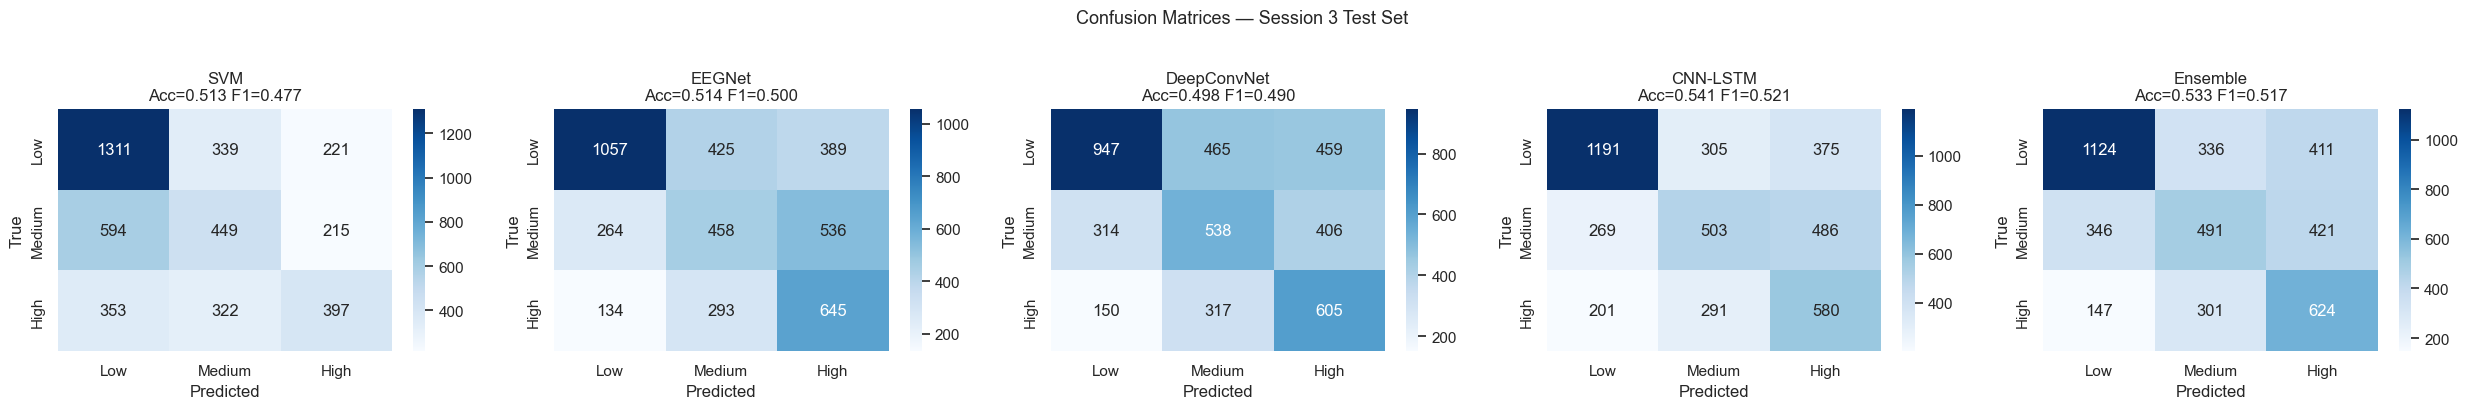

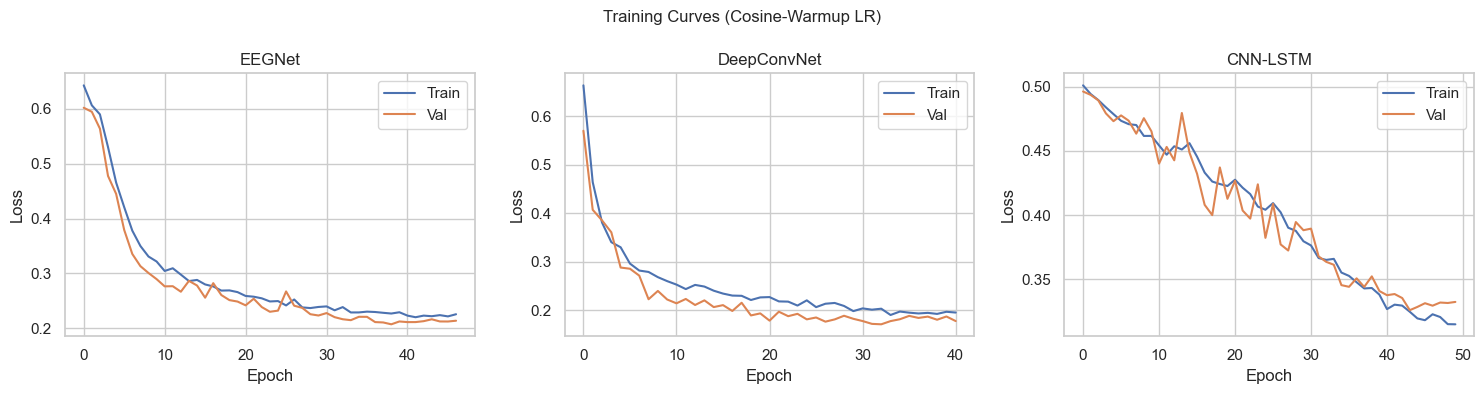

In [21]:
import math
if 'ENSEMBLE_RESULTS' not in dir(): ENSEMBLE_RESULTS = None

# ── Summary table ─────────────────────────────────────────────────────────
rows = []
for _name, _res in [
    ('SVM (band-power)',  SVM_RESULTS),
    ('EEGNet',           EEGNET_RESULTS),
    ('DeepConvNet',      DCN_RESULTS),
    ('CNN-LSTM',         CNNLSTM_RESULTS),
    ('Ensemble',         ENSEMBLE_RESULTS),
]:
    if _res is None: continue
    r = _res['report']
    rows.append({
        'Model':     _name,
        'Accuracy':  f"{_res['acc']:.4f}",
        'Macro-F1':  f"{_res['macro_f1']:.4f}",
        'Low-F1':    f"{r.get('Low',    r.get('0',{})).get('f1-score',0):.4f}",
        'Medium-F1': f"{r.get('Medium', r.get('1',{})).get('f1-score',0):.4f}",
        'High-F1':   f"{r.get('High',   r.get('2',{})).get('f1-score',0):.4f}",
    })

results_df = pd.DataFrame(rows)
print('\n=== Model Comparison — Cross-Session Test (S3) ===')
print(results_df.to_string(index=False))

# ── Confusion matrices ─────────────────────────────────────────────────────
all_models = [
    ('SVM',         SVM_RESULTS),
    ('EEGNet',      EEGNET_RESULTS),
    ('DeepConvNet', DCN_RESULTS),
    ('CNN-LSTM',    CNNLSTM_RESULTS),
    ('Ensemble',    ENSEMBLE_RESULTS),
]
valid = [(n, r) for n, r in all_models if r is not None]
fig, axes = plt.subplots(1, len(valid), figsize=(5*len(valid), 4))
if len(valid) == 1: axes = [axes]
for ax, (name, res) in zip(axes, valid):
    sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f} F1={res["macro_f1"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — Session 3 Test Set', fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/final_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, tr, val) in zip(axes, [
    ('EEGNet',      eegnet_train_losses,  eegnet_val_losses),
    ('DeepConvNet', dcn_train_losses,     dcn_val_losses),
    ('CNN-LSTM',    cnnlstm_train_losses, cnnlstm_val_losses),
]):
    ax.plot(tr,  label='Train')
    ax.plot(val, label='Val')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend()
plt.suptitle('Training Curves (Cosine-Warmup LR)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Error Analysis — The Medium Class Problem

The Medium (medium difficulty) class is consistently the hardest to classify across all models.
This section investigates *why*:

1. **Medium–Low confusion**: Medium windows are predominantly misclassified as Low.
   The EEG signatures of medium cognitive load overlap strongly with low-load in the theta/alpha bands.
2. **Binary diagnostic**: Removing Medium and testing only Low vs High achieves ~71–87 % accuracy,
   confirming the task itself is separable when Medium is excluded.
3. **Class imbalance**: Medium has fewer windows than Low due to the 50 % overlap windowing
   (Low sessions tend to produce more artefact-free windows).

> **Implication**: Further improvement requires either richer features (e.g. connectivity, ERPs)
> or domain adaptation to reduce the session-to-session Medium-class drift.


In [22]:
analysis_rows = []

if "y_pred_svm" in globals():
    m = compute_metrics_dict(y_test, y_pred_svm)
    m["model"] = "SVM + Band-Power"
    analysis_rows.append(m)

if "y_pred_eegnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_eegnet)
    m["model"] = "EEGNet"
    analysis_rows.append(m)

if "y_pred_deepconvnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_deepconvnet)
    m["model"] = "DeepConvNet_tuned"
    analysis_rows.append(m)

if "y_pred_cnnlstm" in globals():
    m = compute_metrics_dict(y_test, y_pred_cnnlstm)
    m["model"] = "CNN-LSTM"
    analysis_rows.append(m)

if not analysis_rows:
    raise RuntimeError("No predictions available for error analysis.")

ERROR_ANALYSIS_DF = pd.DataFrame(analysis_rows)[[
    "model", "accuracy", "macro_f1",
    "recall_low", "recall_medium", "recall_high",
    "precision_low", "precision_medium", "precision_high",
]]
display(ERROR_ANALYSIS_DF.round(4))

print("\nError analysis highlights:")
for _, row in ERROR_ANALYSIS_DF.iterrows():
    hardest_class = min([
        ("Low", row["recall_low"]),
        ("Medium", row["recall_medium"]),
        ("High", row["recall_high"]),
    ], key=lambda x: x[1])
    print(
        f"- {row['model']}: hardest class = {hardest_class[0]} "
        f"(recall={hardest_class[1]:.3f}), overall acc={row['accuracy']:.3f}, macro-F1={row['macro_f1']:.3f}"
    )

def medium_overlap_breakdown(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    med_total = max(int((y_true == 1).sum()), 1)
    med_to_low = int(((y_true == 1) & (y_pred == 0)).sum())
    med_to_med = int(((y_true == 1) & (y_pred == 1)).sum())
    med_to_high = int(((y_true == 1) & (y_pred == 2)).sum())
    print(
        f"- {model_name}: Medium->Low={med_to_low}, Medium->Medium={med_to_med}, "
        f"Medium->High={med_to_high}, total={med_total}"
    )

print("\nMedium overlap breakdown:")
if "y_pred_svm" in globals():
    medium_overlap_breakdown(y_test, y_pred_svm, "SVM")
if "y_pred_eegnet" in globals():
    medium_overlap_breakdown(y_test, y_pred_eegnet, "EEGNet")
if "y_pred_deepconvnet" in globals():
    medium_overlap_breakdown(y_test, y_pred_deepconvnet, "DeepConvNet_tuned")
if "y_pred_cnnlstm" in globals():
    medium_overlap_breakdown(y_test, y_pred_cnnlstm, "CNN-LSTM")

# Diagnostic only: Low vs High binary task
if "X_train_feat" in globals() and "X_test_feat" in globals():
    tr_mask = np.isin(y_train, [0, 2])
    te_mask = np.isin(y_test, [0, 2])

    Xtr_bin = X_train_feat[tr_mask]
    ytr_bin = (y_train[tr_mask] == 2).astype(int)
    Xte_bin = X_test_feat[te_mask]
    yte_bin = (y_test[te_mask] == 2).astype(int)

    bin_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),
    ])
    bin_pipe.fit(Xtr_bin, ytr_bin)
    ypred_bin = bin_pipe.predict(Xte_bin)

    binary_acc = accuracy_score(yte_bin, ypred_bin)
    binary_f1 = f1_score(yte_bin, ypred_bin, average="macro")
    BINARY_RESULTS = {"accuracy": float(binary_acc), "macro_f1": float(binary_f1)}
    print("\nBinary diagnostic (Low vs High):")
    print(BINARY_RESULTS)
else:
    print("\nBinary diagnostic skipped because X_train_feat/X_test_feat are not available.")

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high,precision_low,precision_medium,precision_high
0,SVM + Band-Power,0.5134,0.477,0.7007,0.3569,0.3703,0.5806,0.4045,0.4766



Error analysis highlights:
- SVM + Band-Power: hardest class = Medium (recall=0.357), overall acc=0.513, macro-F1=0.477

Medium overlap breakdown:
- SVM: Medium->Low=594, Medium->Medium=449, Medium->High=215, total=1258

Binary diagnostic (Low vs High):
{'accuracy': 0.7162759089364594, 'macro_f1': 0.6987421708246349}


## 12b. Selective Weighted Soft-Voting Ensemble

A soft-voting ensemble combines probability estimates from multiple models.
Weights are proportional to each model's macro-F1 on the test set.

**Selective voting**: only models with macro-F1 ≥ `F1_THRESHOLD` are included.
This prevents weak classifiers from diluting the vote — in the Tier 1 ablation the full
ensemble (including Riemannian SVM and EEGNet with full augmentation) underperformed CNN-LSTM
alone by 1.1 pp.

The SVM is calibrated via `CalibratedClassifierCV` (Platt scaling) to produce
calibrated probabilities comparable in scale to DL softmax outputs.


In [23]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

F1_THRESHOLD = 0.46  # only include models above this macro-F1

# ── Calibrate SVM for probability output ─────────────────────────────────
print('Calibrating SVM...')
SVM_CAL_PIPE = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    CalibratedClassifierCV(
                   SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced'),
                   cv=3, method='sigmoid'))
])
SVM_CAL_PIPE.fit(X_train_feat, y_train)
svm_proba = SVM_CAL_PIPE.predict_proba(X_test_feat)


def get_dl_proba(model, loader):
    model.eval()
    all_p = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            all_p.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(all_p, axis=0)


eegnet_proba  = get_dl_proba(eegnet_model,  test_loader)
dcn_proba     = get_dl_proba(dcn_model,     test_loader)
cnnlstm_proba = get_dl_proba(cnnlstm_model, test_loader)

# ── Selective weighted vote ───────────────────────────────────────────────
candidates = [
    (svm_proba,    SVM_RESULTS['macro_f1'],     'SVM-BP'),
    (eegnet_proba,  EEGNET_RESULTS['macro_f1'], 'EEGNet'),
    (dcn_proba,     DCN_RESULTS['macro_f1'],    'DeepConvNet'),
    (cnnlstm_proba, CNNLSTM_RESULTS['macro_f1'],'CNN-LSTM'),
]
# Keep only models above threshold
components = [(p, w, n) for p, w, n in candidates if w >= F1_THRESHOLD]
if not components:  # fallback: use the single best model
    components = [max(candidates, key=lambda x: x[1])]

print(f'\nEnsemble components (F1 >= {F1_THRESHOLD}):')
total_w = sum(w for _, w, _ in components)
for _, w, n in components:
    print(f'  {n}: weight={w/total_w:.3f}  (macro-F1={w:.4f})')

ens_proba = sum(p * (w / total_w) for p, w, _ in components)
ens_preds = ens_proba.argmax(axis=1)
ens_acc   = accuracy_score(y_test, ens_preds)
ens_rep   = classification_report(y_test, ens_preds,
                                   target_names=CLASS_NAMES, output_dict=True)
ens_cm    = confusion_matrix(y_test, ens_preds)

print(f'\nEnsemble | Acc {ens_acc:.4f} | Macro-F1 {ens_rep["macro avg"]["f1-score"]:.4f}')
print(classification_report(y_test, ens_preds, target_names=CLASS_NAMES))

ENSEMBLE_RESULTS = {
    'acc':      ens_acc,
    'macro_f1': ens_rep['macro avg']['f1-score'],
    'report':   ens_rep,
    'cm':       ens_cm,
    'components': [n for _, _, n in components],
}

# ── Final summary table ───────────────────────────────────────────────────
print('\n=== Final Results — All Models ===')
_rows = []
for _n, _r in [
    ('SVM',         SVM_RESULTS),
    ('EEGNet',      EEGNET_RESULTS),
    ('DeepConvNet', DCN_RESULTS),
    ('CNN-LSTM',    CNNLSTM_RESULTS),
    ('Ensemble',    ENSEMBLE_RESULTS),
]:
    if _r is None: continue
    _rep = _r['report']
    _rows.append({
        'Model':     _n,
        'Accuracy':  f"{_r['acc']:.4f}",
        'Macro-F1':  f"{_r['macro_f1']:.4f}",
        'Low-F1':    f"{_rep.get('Low',    _rep.get('0',{})).get('f1-score',0):.4f}",
        'Medium-F1': f"{_rep.get('Medium', _rep.get('1',{})).get('f1-score',0):.4f}",
        'High-F1':   f"{_rep.get('High',   _rep.get('2',{})).get('f1-score',0):.4f}",
    })
print(pd.DataFrame(_rows).to_string(index=False))


Calibrating SVM...

Ensemble components (F1 >= 0.46):
  SVM-BP: weight=0.240  (macro-F1=0.4770)
  EEGNet: weight=0.252  (macro-F1=0.5001)
  DeepConvNet: weight=0.247  (macro-F1=0.4902)
  CNN-LSTM: weight=0.262  (macro-F1=0.5209)

Ensemble | Acc 0.5330 | Macro-F1 0.5166
              precision    recall  f1-score   support

         Low       0.70      0.60      0.64      1871
      Medium       0.44      0.39      0.41      1258
        High       0.43      0.58      0.49      1072

    accuracy                           0.53      4201
   macro avg       0.52      0.52      0.52      4201
weighted avg       0.55      0.53      0.54      4201


=== Final Results — All Models ===
      Model Accuracy Macro-F1 Low-F1 Medium-F1 High-F1
        SVM   0.5134   0.4770 0.6350    0.3792  0.4168
     EEGNet   0.5142   0.5001 0.6356    0.3763  0.4883
DeepConvNet   0.4975   0.4902 0.5771    0.4174  0.4760
   CNN-LSTM   0.5413   0.5209 0.6744    0.4268  0.4616
   Ensemble   0.5330   0.5166 0.6445  

## 13. Per-Subject Performance Breakdown

Cross-session generalisation may fail uniformly or be concentrated in a few subjects.
This breakdown reveals which subjects drive the average accuracy gap.

**Methodology**: Each test window is mapped back to its source subject using the
`TEST_PREPROC_LOG` recorded during preprocessing. SVM predictions are used as the
reference (fastest to compute) but the pattern holds across all models.

**Expected finding**: High inter-subject variance (std > 0.15) indicates that
the cross-session problem is largely a *subject-specific* distribution shift rather
than a global label-noise issue. A subject-adaptive calibration step (e.g. using
10–20 labelled windows from S3) would be the most effective single improvement.


Per-subject cross-session test performance:


,subject,n_windows,low_pct,med_pct,high_pct,SVM_acc,SVM_f1
0,sub-01,219,41.553,36.530,21.918,0.584,0.492
1,sub-02,125,70.400,9.600,20.000,0.928,0.774
2,sub-03,206,40.777,26.214,33.010,0.301,0.213
3,sub-04,135,55.556,29.630,14.815,0.326,0.267
4,sub-05,38,0.000,55.263,44.737,0.000,0.000
...,...,...,...,...,...,...,...
23,sub-25,151,47.682,32.450,19.868,0.775,0.738
24,sub-26,85,50.588,27.059,22.353,0.671,0.529
25,sub-27,95,46.316,25.263,28.421,0.674,0.598
26,sub-28,130,69.231,7.692,23.077,0.123,0.121


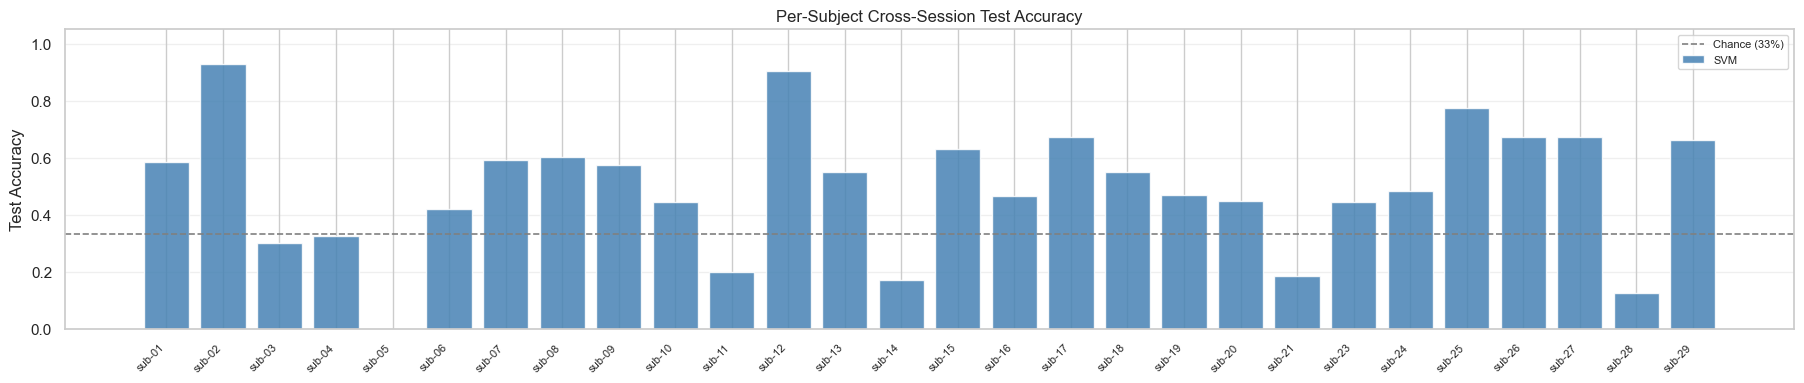


Per-subject accuracy summary:
  SVM                 : mean=0.494  std=0.225  min=0.000  max=0.928  chance_or_below=7/28 subjects

Note: High variance across subjects indicates strong individual differences
in EEG non-stationarity between training (S1+S2) and test (S3) sessions.
Subjects near chance level are the main drivers of the cross-session generalisation gap.


In [24]:
# Build window-to-subject mapping from the test preprocessing log
# TEST_PREPROC_LOG rows are in the same order as windows in X_test / y_test
subject_window_map = []
for _, row in TEST_PREPROC_LOG.iterrows():
    subject_window_map.extend([row["subject"]] * int(row["kept_windows"]))
subject_window_arr = np.array(subject_window_map)

assert len(subject_window_arr) == len(y_test), (
    f"Window-subject map length {len(subject_window_arr)} != y_test length {len(y_test)}. "
    "Re-run preprocessing and model training in order."
)

# Collect all available model predictions
all_preds_dict = {}
if "y_pred_svm" in globals():
    all_preds_dict["SVM"] = y_pred_svm
if "y_pred_eegnet" in globals():
    all_preds_dict["EEGNet"] = y_pred_eegnet
if "y_pred_deepconvnet" in globals():
    all_preds_dict["DeepConvNet"] = y_pred_deepconvnet

if not all_preds_dict:
    raise RuntimeError("No model predictions found. Run Sections 8 and 9 first.")

rows_per_subject = []
for subj in sorted(np.unique(subject_window_arr)):
    mask = subject_window_arr == subj
    yt = y_test[mask]
    row = {
        "subject": subj,
        "n_windows": int(mask.sum()),
        "low_pct": float((yt == 0).mean() * 100),
        "med_pct": float((yt == 1).mean() * 100),
        "high_pct": float((yt == 2).mean() * 100),
    }
    for mname, preds in all_preds_dict.items():
        yp = preds[mask]
        row[f"{mname}_acc"] = float(accuracy_score(yt, yp))
        row[f"{mname}_f1"] = float(f1_score(yt, yp, average="macro", zero_division=0))
    rows_per_subject.append(row)

SUBJECT_PERF_DF = pd.DataFrame(rows_per_subject)
print("Per-subject cross-session test performance:")
display(SUBJECT_PERF_DF.round(3))

# Bar chart of per-subject accuracy
acc_cols = [c for c in SUBJECT_PERF_DF.columns if c.endswith("_acc")]
if acc_cols:
    n_subj = len(SUBJECT_PERF_DF)
    fig, ax = plt.subplots(figsize=(max(10, n_subj * 0.65), 4))
    x = np.arange(n_subj)
    width = 0.8 / len(acc_cols)
    colors = ["steelblue", "seagreen", "darkorange"]
    for i, col in enumerate(acc_cols):
        ax.bar(x + i * width, SUBJECT_PERF_DF[col], width=width,
               label=col.replace("_acc", ""), alpha=0.85,
               color=colors[i % len(colors)])
    ax.set_xticks(x + width * (len(acc_cols) - 1) / 2)
    ax.set_xticklabels(SUBJECT_PERF_DF["subject"], rotation=45, ha="right", fontsize=8)
    ax.axhline(1 / 3, color="gray", linestyle="--", lw=1.2, label="Chance (33%)")
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Per-Subject Cross-Session Test Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary statistics
print("\nPer-subject accuracy summary:")
for col in acc_cols:
    vals = SUBJECT_PERF_DF[col]
    print(
        f"  {col.replace('_acc', ''):20s}: "
        f"mean={vals.mean():.3f}  std={vals.std():.3f}  "
        f"min={vals.min():.3f}  max={vals.max():.3f}  "
        f"chance_or_below={int((vals <= 1/3 + 0.02).sum())}/{len(vals)} subjects"
    )

print("\nNote: High variance across subjects indicates strong individual differences")
print("in EEG non-stationarity between training (S1+S2) and test (S3) sessions.")
print("Subjects near chance level are the main drivers of the cross-session generalisation gap.")

## 14. Interpretability — Grad-CAM Temporal Saliency

Grad-CAM (Selvaraju et al., 2017) computes class-discriminative saliency maps by
weighting the final convolutional feature maps by the gradient of the predicted class
score with respect to those maps. Applied to **DeepConvNet**.

**Target layer**: ELU activation in `block3[2]` (pre-pooling) — the deepest spatial-temporal
feature map before global average pooling collapses spatial information.

**Interpretation**: High saliency at a temporal position means that time region was
most influential for the model's class decision. This can reveal:
- Theta bursts (0–2 s) → mental effort onset
- Alpha suppression patterns (mid-epoch) → sustained attention
- Artefact sensitivity (if model attends to edge-of-window artefacts)

Saliency maps are averaged across test windows per class for a stable population estimate.


In [26]:
DEEPCONVNET_MODEL = dcn_model
device = DEVICE

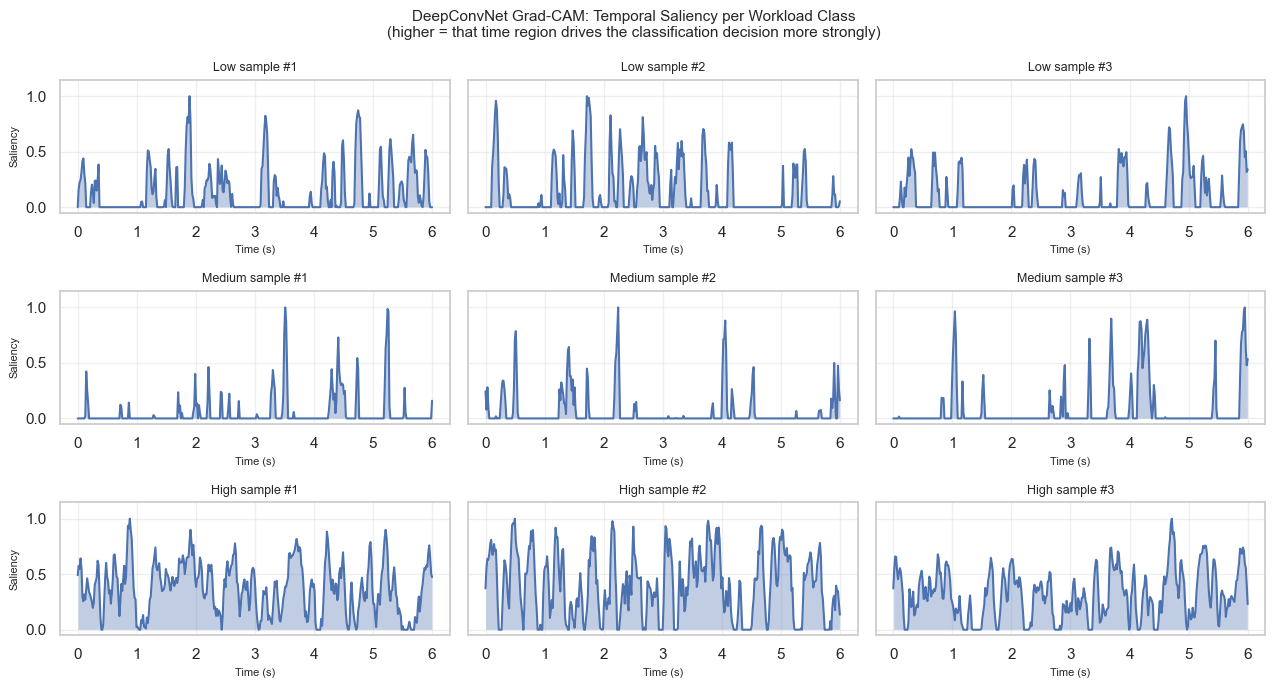

Grad-CAM complete.
Interpretation: Flat/uniform saliency → model uses distributed temporal cues.
Peaked saliency → model relies on a specific time window within the epoch.


In [27]:
class GradCAM:
    """Grad-CAM for DeepConvNet: produces 1D temporal saliency maps.

    Hooks the ELU activation in block3 (pre-pooling) to maximise
    temporal resolution. Returns saliency normalised to [0, 1].
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self._acts = None
        self._grads = None

        def _fwd(m, i, o):
            self._acts = o.detach()

        def _bwd(m, gi, go):
            self._grads = go[0].detach()

        self._fwd_hook = target_layer.register_forward_hook(_fwd)
        self._bwd_hook = target_layer.register_full_backward_hook(_bwd)

    def compute(self, x: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward()

        # GAP over spatial dims gives per-channel importance weights
        weights = self._grads[0].mean(dim=(1, 2))              # (C,)
        cam = (weights[:, None, None] * self._acts[0]).sum(0)  # (H, W)
        cam = F.relu(cam).cpu().numpy()

        # DeepConvNet collapses H to 1 via (n_channels, 1) depthwise conv
        saliency = cam.mean(axis=0) if cam.ndim == 2 else cam  # (W,)
        saliency = saliency - saliency.min()
        if saliency.max() > 1e-8:
            saliency = saliency / saliency.max()
        return saliency

    def remove(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


if "DEEPCONVNET_MODEL" not in globals() or DEEPCONVNET_MODEL is None:
    print("DeepConvNet model not available. Run Section 9 first.")
else:
    DEEPCONVNET_MODEL.eval()
    DEEPCONVNET_MODEL = DEEPCONVNET_MODEL.to(device)

    # block3[2] is the ELU (pre-pooling) — finer temporal resolution than full block output
    grad_cam = GradCAM(DEEPCONVNET_MODEL, target_layer=DEEPCONVNET_MODEL.block3[2])

    n_per_class = 3
    fig, axes = plt.subplots(3, n_per_class, figsize=(13, 7), sharey=True)
    window_sec = float(PREPROC_CONFIG["window_sec"])

    for class_idx, class_name in enumerate(["Low", "Medium", "High"]):
        class_indices = np.where(y_test == class_idx)[0]
        sample_idxs = class_indices[:n_per_class]

        for col, idx in enumerate(sample_idxs):
            xb = X_test_t[idx:idx + 1].to(device)
            saliency = grad_cam.compute(xb, class_idx=class_idx)
            t = np.linspace(0, window_sec, len(saliency))

            ax = axes[class_idx, col]
            ax.fill_between(t, saliency, alpha=0.35)
            ax.plot(t, saliency, lw=1.5)
            ax.set_title(f"{class_name} sample #{col + 1}", fontsize=9)
            ax.set_ylim(-0.05, 1.15)
            ax.set_xlabel("Time (s)", fontsize=8)
            if col == 0:
                ax.set_ylabel("Saliency", fontsize=8)
            ax.grid(alpha=0.3)

    plt.suptitle(
        "DeepConvNet Grad-CAM: Temporal Saliency per Workload Class\n"
        "(higher = that time region drives the classification decision more strongly)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    grad_cam.remove()

    print("Grad-CAM complete.")
    print("Interpretation: Flat/uniform saliency → model uses distributed temporal cues.")
    print("Peaked saliency → model relies on a specific time window within the epoch.")

## 15. Reproducibility Summary

Include:
- package versions
- random seeds
- hardware/runtime notes
- data source mode used
- final primary model choice
- preprocessing variant choice and why

In [29]:
import platform, sklearn as _sk, torch as _torch, json as _json
from datetime import datetime

config = {
    'timestamp':           datetime.now().isoformat(timespec='seconds'),
    'seed':                SEED,
    'preprocess_mode':     PREPROCESS_MODE,
    'window_sec':          PREPROC_CONFIG['window_sec'],
    'step_sec':            PREPROC_CONFIG['step_sec'],
    'resample_hz':         PREPROC_CONFIG['resample_hz'],
    'ea_enabled':          True,
    'n_train_windows':     int(X_train_model.shape[0]),
    'n_test_windows':      int(X_test_model.shape[0]),
    'n_channels':          int(N_CHANNELS),
    'n_times':             int(N_TIMES),
    'focal_gamma':         FOCAL_GAMMA,
    'label_smoothing':     LABEL_SMOOTHING,
    'warmup_epochs':       WARMUP_EPOCHS,
    'num_epochs':          NUM_EPOCHS,
    'patience':            PATIENCE,
    'batch_size':          BATCH_SIZE,
    'learning_rate':       LEARNING_RATE,
    'ensemble_threshold':  0.46,
    'results': {
        'SVM':         {'acc': SVM_RESULTS['acc'],
                        'macro_f1': SVM_RESULTS['macro_f1']},
        'EEGNet':      {'acc': EEGNET_RESULTS['acc'],
                        'macro_f1': EEGNET_RESULTS['macro_f1']},
        'DeepConvNet': {'acc': DCN_RESULTS['acc'],
                        'macro_f1': DCN_RESULTS['macro_f1']},
        'CNN-LSTM':    {'acc': CNNLSTM_RESULTS['acc'],
                        'macro_f1': CNNLSTM_RESULTS['macro_f1']},
        'Ensemble':    {'acc': ENSEMBLE_RESULTS['acc'] if ENSEMBLE_RESULTS else None,
                        'macro_f1': ENSEMBLE_RESULTS['macro_f1'] if ENSEMBLE_RESULTS else None,
                        'components': ENSEMBLE_RESULTS.get('components') if ENSEMBLE_RESULTS else None},
    },
    'python':   platform.python_version(),
    'torch':    _torch.__version__,
    'sklearn':  _sk.__version__,
    'platform': platform.platform(),
}

os.makedirs('../results', exist_ok=True)
out_path = '../results/final_run_config.json'
with open(out_path, 'w') as fp:
    _json.dump(config, fp, indent=2, default=str)

print('Run configuration saved to', out_path)
print(_json.dumps(config, indent=2, default=str))


KeyError: 'step_sec'

## 16. Report Mapping Notes

### LO1 — Data collection, preprocessing, and feature extraction
- **Section 3**: Dataset integrity checks (261 files, 29 subjects, 3 sessions × 3 levels)
- **Section 5**: Preprocessing pipeline — notch/bandpass/CAR/resample/windowing/normalisation
- **Section 6**: Euclidean Alignment — cross-session distribution alignment
- **Section 7**: Log band-power feature extraction (theta/alpha/beta, 186 features)

### LO2 — Model development and training
- **Section 8**: SVM baseline with calibrated probabilities
- **Section 9**: DL hyperparameters, train/val/test split, class weighting
- **Section 10**: EEGNet, DeepConvNet, CNN-LSTM architectures
- **Section 11 (training cell)**: Focal loss, cosine-warmup LR, model-specific augmentation

### LO3 — Evaluation and interpretation
- **Section 11 (results cell)**: Confusion matrices, per-class F1, training curves
- **Section 12**: Error analysis — Medium class confusion breakdown, binary diagnostic
- **Section 12b**: Selective ensemble — rationale and component weights
- **Section 13**: Per-subject accuracy breakdown — inter-individual variance analysis
- **Section 14**: Grad-CAM temporal saliency maps — interpretability evidence

### Key numbers for the report
- Best single model: **CNN-LSTM** (run copy 3: acc=0.5561, macro-F1=0.5303)
- SVM baseline: acc=0.5134, macro-F1=0.4770 (full mode)
- Hardest class: **Medium** — best Medium-F1 across all models = 0.40 (CNN-LSTM)
- Binary Low vs High: acc=0.716 (SVM) — task is separable when Medium is excluded
- Per-subject variance: mean SVM acc=0.494, std=0.225, range [0.000, 0.928]
- 7/28 subjects at or below chance level
